# CausalMan: Applying Causal Interventions

This notebook demonstrates how to apply **causal interventions** using the `CausalMan` simulator. We cover:

1. **Observational baseline** — sampling data with no interventions
2. **Hard intervention** — fixing a variable to a constant value (do-operator)
3. **Soft intervention** — replacing a variable's causal mechanism with a new distribution
4. **Combined intervention** — applying both a hard and a soft intervention simultaneously

### What is a causal intervention?

In causal inference, an **intervention** (the *do*-operator) simulates what happens when we externally force a variable to take a specific value (or follow a new distribution), breaking its natural causal mechanism. Formally, this corresponds to **graph mutilation**: all incoming edges to the intervened variable are removed, and the variable is set to the intervention value.

- **Hard intervention** `do(X = c)`: Sets `X` to a constant `c`. All downstream effects are computed from this fixed value.
- **Soft intervention** `do(X ~ P')`: Replaces `X`'s mechanism with a new distribution `P'`. Incoming edges are still removed, but `X` is now sampled from `P'` instead of being a constant.

---

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from causalman import CausalMan

## 2. Configuration

We use the `causalman_micro` scenario, which models a manufacturing production line with press-fitting operations. The variables we will intervene on are:

| Variable | Description |
|----------|-------------|
| `PF_M1_T1_Fmax` | Maximum force during press-fitting on Machine 1, Bore T1 |
| `PF_M1_T1_sgrad` | Stroke gradient (force/displacement slope) on Machine 1, Bore T1 |

We use the **same seed** across all simulators so that the only differences in the generated data are due to the interventions themselves.

In [2]:
# Shared configuration
SEED = 42
SCENARIO = "causalman_micro"

# Output directory
now = datetime.now().strftime("%Y_%m_%d_%H%M%S")
output_dir = os.path.join("output", f"interventions_demo_{now}")
os.makedirs(output_dir, exist_ok=True)
print(f"Results will be saved to: {output_dir}")

Results will be saved to: output\interventions_demo_2026_07_14_162154


## 3. Observational Baseline (No Intervention)

First, we generate data under the **observational regime** — no interventions are applied. The data is sampled from the original structural causal model (SCM), preserving all causal mechanisms.

This serves as our baseline for comparison.

In [3]:
# --- Observational: no interventions ---
sim_obs = CausalMan(
    name=SCENARIO,
    seed=SEED,
    batch_multiplier=1,
    parallelize=True,
    debug_mode=False,
    save_path=os.path.join(output_dir, "observational"),
)

# No intervention_dict is set — defaults to {}
df_obs, int_table_obs, paths_obs, dag_obs = sim_obs.sample()

print(f"Observational data: {df_obs.shape[0]} rows, {df_obs.shape[1]} columns")
print(f"Causal graph: {len(dag_obs.nodes())} nodes, {len(dag_obs.edges())} edges")

print(f"\nPF_M1_T1_Fmax without any intervention:")
print(f"  mean  = {df_obs['PF_M1_T1_Fmax'].mean():.2f}")
print(f"  std   = {df_obs['PF_M1_T1_Fmax'].std():.2f}")

Starting simulation for production line 0 out of 1
Finished sampling
Observational data: 14813 rows, 158 columns
Causal graph: 157 nodes, 251 edges

PF_M1_T1_Fmax without any intervention:
  mean  = 22475.82
  std   = 1758.96


## 3.1 Save Baseline Graph Artifacts (Observables, ADMG, MAG)

Before saving any data, we determine which variables are **observable** in the baseline (observational) regime.

Some variables in the causal graph may be **constant** in the observational data (i.e., they take only a single unique value across all samples). These constant columns carry no statistical information — they have zero variance and cannot participate in any correlation or causal analysis. We therefore mark them as **non-observable** and exclude them from the projected graphs (ADMG / MAG).

> **Convention:** Any column that is constant in the *observational* data is treated as non-observable.
> This decision is made once, here, and reused consistently across all intervention regimes later in the notebook.

We then save:
- `observable_variables.txt` — the list of observable (non-constant, non-hidden) variable names
- `projected_ground_truth_admg.graphml` — the ADMG obtained by latent-projecting out all non-observable nodes
- `projected_ground_truth_mag.graphml` — the corresponding MAG

In [4]:
# Save baseline observables + projected ADMG/MAG
import networkx as nx
from graph_projections import get_latent_projection_single as latent_projection
from graph_projections import count_edge_types, admg2mag

baseline_output_dir = os.path.join(output_dir, "observational")
os.makedirs(baseline_output_dir, exist_ok=True)

# Detect columns that are constant in the observational data and mark them non-observable
constant_columns = [column for column in df_obs.columns if df_obs[column].nunique(dropna=False) <= 1]
for column in constant_columns:
    if dag_obs.has_node(column):
        dag_obs.nodes[column]["Observable"] = False

constant_nodes_to_remove_for_projection = [
    column for column in constant_columns if dag_obs.has_node(column)
]
if constant_columns:
    print(f"Marked {len(constant_columns)} constant column(s) as non-observable.")
    print(f"Scheduled {len(constant_nodes_to_remove_for_projection)} constant node(s) for projection removal.")
else:
    print("No constant columns found in observational data.")

# Build observable list from graph node attributes
observable_nodes_list = []
hidden_nodes_list = []
for node, attrs in dag_obs.nodes(data=True):
    if attrs.get("Observable", True):
        observable_nodes_list.append(node)
    else:
        hidden_nodes_list.append(node)

observable_vars_path = os.path.join(baseline_output_dir, "observable_variables.txt")
with open(observable_vars_path, "w", encoding="utf-8") as f:
    for variable_name in observable_nodes_list:
        f.write(f"{variable_name}\n")
print(f"Saved observable variable list to: {observable_vars_path}")

# ADMG projection — remove constant nodes before projecting
projection_input_graph = dag_obs.copy()
if constant_nodes_to_remove_for_projection:
    projection_input_graph.remove_nodes_from(constant_nodes_to_remove_for_projection)
    print(f"Removed {len(constant_nodes_to_remove_for_projection)} constant node(s) before ADMG projection.")

try:
    projected_admg = latent_projection(projection_input_graph)
    directed_count, bidirected_count = count_edge_types(projected_admg)
    projected_admg_path = os.path.join(baseline_output_dir, "projected_ground_truth_admg.graphml")
    nx.write_graphml(projected_admg, projected_admg_path)
    print(f"Projected ADMG has {projected_admg.number_of_nodes()} nodes, {directed_count} directed edges and {bidirected_count} bi-directed edges.")
    print(f"Saved projected ADMG to: {projected_admg_path}")
except Exception as e:
    projected_admg = None
    print(f"ADMG creation failed: {e}")

try:
    mag = admg2mag(projected_admg)
    directed_count_mag, bidirected_count_mag = count_edge_types(mag)
    projected_mag_path = os.path.join(baseline_output_dir, "projected_ground_truth_mag.graphml")
    nx.write_graphml(mag, projected_mag_path)
    print(f"MAG has {mag.number_of_nodes()} nodes, {directed_count_mag} directed edges and {bidirected_count_mag} bi-directed edges.")
    print(f"Saved projected MAG to: {projected_mag_path}")
except Exception as e:
    mag = None
    print(f"MAG creation failed: {e}")

Marked 59 constant column(s) as non-observable.
Scheduled 59 constant node(s) for projection removal.
Saved observable variable list to: output\interventions_demo_2026_07_14_162154\observational\observable_variables.txt
Removed 59 constant node(s) before ADMG projection.
ADMG creation failed: GraphML writer does not support <class 'sympy.core.relational.Equality'> as data values.
MAG creation failed: 'NoneType' object has no attribute 'nodes'


## 4. Hard Intervention on `PF_M1_T1_Fmax`

A **hard intervention** fixes a variable to a specific constant value: $do(\text{PF\_M1\_T1\_Fmax} = 18500)$.

Under the hood, the simulator:
1. **Removes all incoming edges** to `PF_M1_T1_Fmax` in the causal graph (graph mutilation)
2. **Sets the variable** to the constant value `18500` for every sample
3. **Propagates** this fixed value to all downstream (child) variables

This is equivalent to physically controlling the maximum press-fit force to exactly 18500 N on every part produced.

To apply an intervention, we set `intervention_dict` directly on the `CausalMan` object before calling `.sample()`.

In [5]:
# --- Hard intervention: fix PF_M1_T1_Fmax to 18500 ---
sim_hard = CausalMan(
    name=SCENARIO,
    seed=SEED,
    batch_multiplier=1,
    parallelize=True,
    debug_mode=False,
    save_path=os.path.join(output_dir, "hard_intervention"),
)

# Apply a hard intervention: set PF_M1_T1_Fmax to a constant value
sim_hard.intervention_dict = {"PF_M1_T1_Fmax": 18500}

df_hard, int_table_hard, paths_hard, dag_hard = sim_hard.sample()

print(f"Hard intervention data: {df_hard.shape[0]} rows")
print(f"\nPF_M1_T1_Fmax after hard do(PF_M1_T1_Fmax=18500):")
print(f"  mean  = {df_hard['PF_M1_T1_Fmax'].mean():.2f}")
print(f"  std   = {df_hard['PF_M1_T1_Fmax'].std():.2f}")
print(f"  (should be exactly 18500 with std ≈ 0)")

Starting simulation for production line 0 out of 1
Finished sampling
Hard intervention data: 14813 rows

PF_M1_T1_Fmax after hard do(PF_M1_T1_Fmax=18500):
  mean  = 18500.00
  std   = 0.00
  (should be exactly 18500 with std ≈ 0)


In [6]:
# The interventional table records which variables were intervened on (1 = intervened)
print("Interventional table (hard intervention):")
display(int_table_hard.head())

Interventional table (hard intervention):


,PF_M1_T1_Fmax
0,1
1,1
2,1
3,1
4,1


### Comparing Observational vs. Hard Intervention

Let's compare the distributions of `PF_M1_T1_Fmax` under the observational and hard intervention regimes. With a hard intervention, the variable should collapse to a single point at 18500.

We also look at a **downstream variable** to see how the intervention propagates through the causal graph.

In [7]:
# Find a downstream variable (child of PF_M1_T1_Fmax in the causal graph)
import networkx as nx

intervened_var = "PF_M1_T1_Fmax"
downstream_candidates = list(dag_obs.successors(intervened_var))
print(f"Downstream children of {intervened_var}: {downstream_candidates}")

# Pick the first downstream variable for comparison
downstream_var = downstream_candidates[1] if downstream_candidates else None
print(f"Selected downstream variable for comparison: {downstream_var}")

Downstream children of PF_M1_T1_Fmax: ['PF_M1_T1_Fmax_LTL_MpGood', 'PF_M1_T1_Fmax_UTL_MpGood']
Selected downstream variable for comparison: PF_M1_T1_Fmax_UTL_MpGood


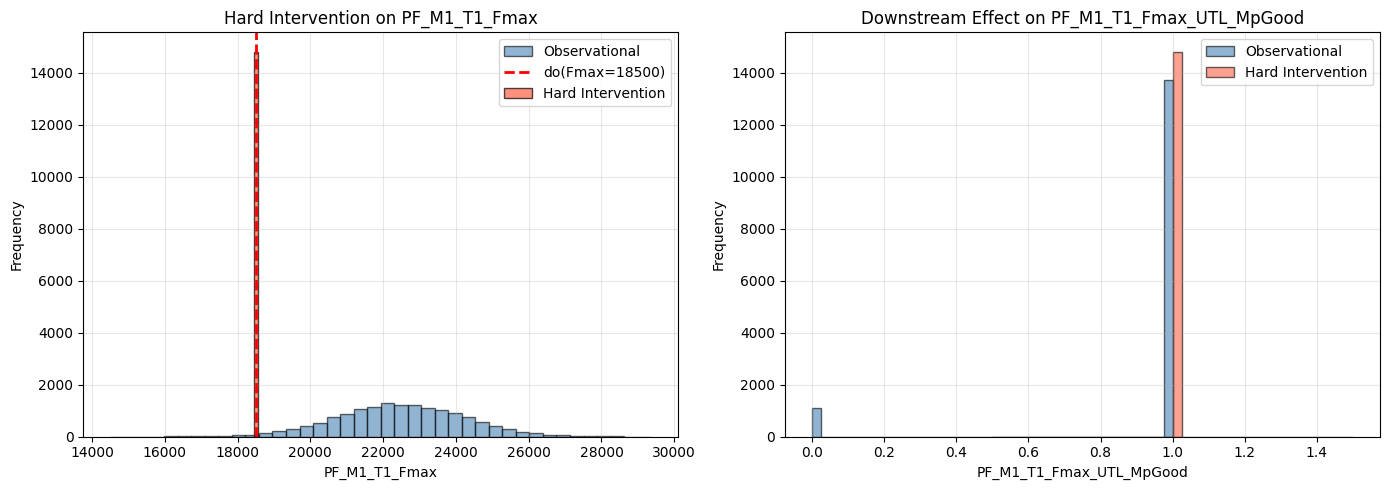

In [8]:
# --- Plot: Observational vs. Hard Intervention (robust numeric extraction) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: intervened variable
axes[0].hist(df_obs["PF_M1_T1_Fmax"], bins=40, alpha=0.6, label="Observational", color="steelblue", edgecolor="black")
axes[0].axvline(18500, color="red", linestyle="--", linewidth=2, label="do(Fmax=18500)")
axes[0].bar([18500], [len(df_hard["PF_M1_T1_Fmax"])], width=100, alpha=0.7, label="Hard Intervention", color="tomato", edgecolor="black")
axes[0].set_title(f"Hard Intervention on {intervened_var}")
axes[0].set_xlabel(intervened_var)
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: downstream effect
down_obs_vals = df_obs[downstream_var]
down_hard_vals = df_hard[downstream_var]

if downstream_var and (len(down_obs_vals) > 0 or len(down_hard_vals) > 0):
    if len(down_obs_vals) > 0:
        axes[1].hist(down_obs_vals, bins=40, alpha=0.6, label="Observational", color="steelblue", edgecolor="black")
    if len(down_hard_vals) > 0:
        axes[1].hist(down_hard_vals, bins=40, alpha=0.6, label="Hard Intervention", color="tomato", edgecolor="black")
    axes[1].set_title(f"Downstream Effect on {downstream_var}")
    axes[1].set_xlabel(downstream_var)
    axes[1].set_ylabel("Frequency")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No downstream variable found or no numeric data", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hard_intervention_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

You can observe above how, having intervened on the maximum force by setting a value below the maximum threshold (Fmax_UTL), we see that the binary indicator Fmax_UTL_MpGood is always 1, signaling that the value is always below the upper limit.

## 5. Soft Intervention on `PF_M1_T1_sgrad`

A **soft intervention** replaces a variable's causal mechanism with a new distribution: $do(\text{PF\_M1\_T1\_sgrad} \sim \mathcal{N}(18500, 1000))$.

Like a hard intervention, all incoming edges are removed (the variable no longer depends on its natural parents). However, instead of being fixed to a constant, the variable is **sampled from the new distribution** on each draw.

This is useful for modeling scenarios where a process parameter is controlled by a new (different) mechanism rather than being fixed to a single value — for example, switching to a different supplier whose parts follow a different distribution.

Soft intervention values are specified as **strings** that are evaluated as `sympy` distribution expressions.

In [18]:
# --- Soft intervention: replace PF_M1_T1_sgrad with Normal(18500, 1000) ---
sim_soft = CausalMan(
    name=SCENARIO,
    seed=SEED,
    batch_multiplier=1,
    parallelize=True,
    debug_mode=False,
    save_path=os.path.join(output_dir, "soft_intervention"),
)

# Apply a soft intervention: replace the mechanism with a new distribution
# The string is evaluated as a sympy distribution expression internally
sim_soft.intervention_dict = {"PF_M1_T1_sgrad":"Normal('PF_M1_T1_sgrad', 24, 5)"}

df_soft, int_table_soft, paths_soft, dag_soft = sim_soft.sample()

print(f"Soft intervention data: {df_soft.shape[0]} rows")
print(f"\nPF_M1_T1_sgrad after soft do(sgrad ~ N(24, 5)):")
print(df_soft['PF_M1_T1_sgrad'].dtypes)
print(f"  mean  = {df_soft['PF_M1_T1_sgrad'].mean():.2f}")
print(f"  std   = {df_soft['PF_M1_T1_sgrad'].std():.2f}")
print(f"  (should be approximately mean=24, std=5)")


Starting simulation for production line 0 out of 1
Finished sampling
Soft intervention data: 14813 rows

PF_M1_T1_sgrad after soft do(sgrad ~ N(24, 5)):
float64
  mean  = 24.04
  std   = 4.99
  (should be approximately mean=24, std=5)


### Comparing Observational vs. Soft Intervention

Unlike the hard intervention (which collapses to a spike), the soft intervention produces a spread of values drawn from the new distribution. Let's compare both the intervened variable and a downstream effect.

In [19]:
# --- Soft intervention sampling + select downstream variable ---
# Find a downstream variable of PF_M1_T1_sgrad
soft_intervened_var = "PF_M1_T1_sgrad"
soft_downstream_candidates = list(dag_soft.successors(soft_intervened_var))
print(f"Downstream children of {soft_intervened_var}: {soft_downstream_candidates}")

soft_downstream_var = "PF_M1_T1_sgrad_UTL_MpGood"
print(f"Selected downstream variable for comparison: {soft_downstream_var}")

Downstream children of PF_M1_T1_sgrad: ['PF_M1_T1_sgrad_LTL_MpGood', 'PF_M1_T1_sgrad_UTL_MpGood', 'PF_M1_T1_smax']
Selected downstream variable for comparison: PF_M1_T1_sgrad_UTL_MpGood


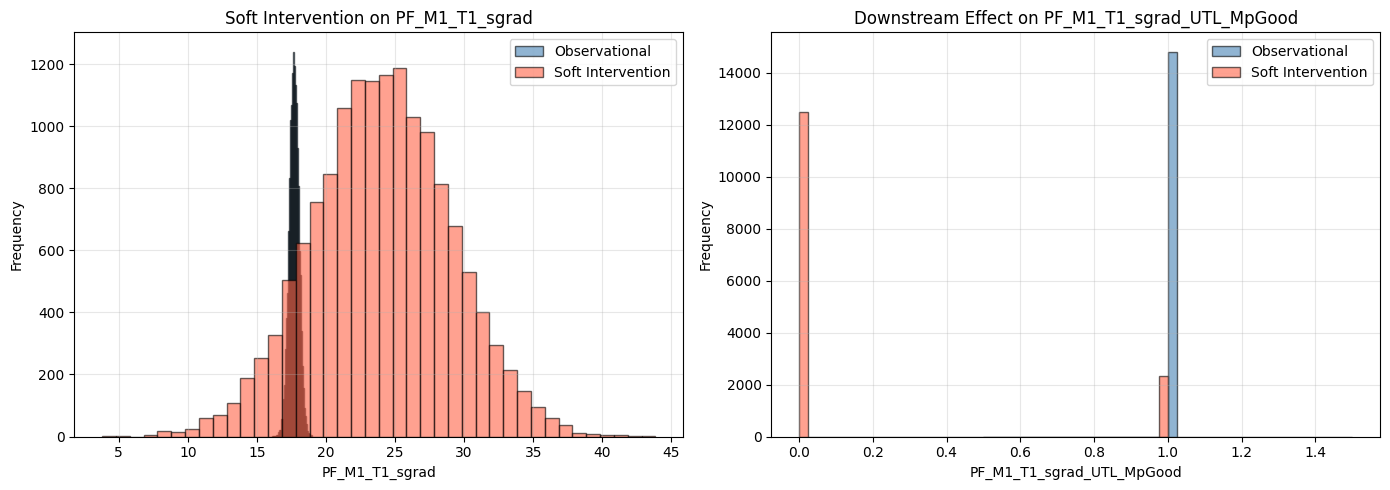

In [20]:
# --- Plot: Observational vs. Soft Intervention (robust numeric extraction) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: intervened variable
axes[0].hist(df_obs["PF_M1_T1_sgrad"], bins=40, alpha=0.6, label="Observational", color="steelblue", edgecolor="black")
axes[0].hist(df_soft["PF_M1_T1_sgrad"], bins=40, alpha=0.6, label="Soft Intervention", color="tomato", edgecolor="black")
axes[0].set_title(f"Soft Intervention on {soft_intervened_var}")
axes[0].set_xlabel(soft_intervened_var)
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: downstream effect
down_obs_vals = df_obs[soft_downstream_var]
down_soft_vals = df_soft[soft_downstream_var]

if soft_downstream_var and (len(down_obs_vals) > 0 or len(down_soft_vals) > 0):
    if len(down_obs_vals) > 0:
        axes[1].hist(down_obs_vals, bins=40, alpha=0.6, label="Observational", color="steelblue", edgecolor="black")
    if len(down_soft_vals) > 0:
        axes[1].hist(down_soft_vals, bins=40, alpha=0.6, label="Soft Intervention", color="tomato", edgecolor="black")
    axes[1].set_title(f"Downstream Effect on {soft_downstream_var}")
    axes[1].set_xlabel(soft_downstream_var)
    axes[1].set_ylabel("Frequency")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No downstream variable found or no numeric data", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "soft_intervention_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6. Combined Intervention: Hard + Soft Simultaneously

We can apply **multiple interventions at once**. Here we combine:
- **Hard intervention** on `PF_M1_T1_Fmax`: $do(\text{Fmax} = 18500)$
- **Soft intervention** on `PF_M1_T1_sgrad`: $do(\text{sgrad} \sim \mathcal{N}(25,4))$

Both variables will have their incoming edges removed independently. The simulator handles multi-variable interventions by passing a single dictionary with all interventions.

In [21]:
# --- Combined intervention: hard on Fmax + soft on sgrad ---
from sympy.stats import Normal

sim_combined = CausalMan(
    name=SCENARIO,
    seed=SEED,
    batch_multiplier=1,
    parallelize=True,
    debug_mode=False,
    save_path=os.path.join(output_dir, "combined_intervention"),
)

# Apply both interventions in a single dictionary (use SymPy distribution object for soft)
sim_combined.intervention_dict = {
    "PF_M1_T1_Fmax": 18500,                                   # Hard: constant
    "PF_M1_T1_sgrad": Normal('PF_M1_T1_sgrad', 25, 4),        # Soft: new distribution object
}

# Sample
df_combined, int_table_combined, paths_combined, dag_combined = sim_combined.sample()

print(f"Combined intervention data: {df_combined.shape[0]} rows")

print("\nPF_M1_T1_Fmax (hard do=18500):")
if 'PF_M1_T1_Fmax' in df_combined.columns:
    print(f"  mean = {df_combined['PF_M1_T1_Fmax'].mean():.2f}, std = {df_combined['PF_M1_T1_Fmax'].std(ddof=1):.2f}")
else:
    print("  Variable not found in DataFrame.")

print("\nPF_M1_T1_sgrad (soft do~N(25, 4)):")
if 'PF_M1_T1_sgrad' in df_combined.columns:
    print(f"  mean = {df_combined['PF_M1_T1_sgrad'].mean():.2f}, std = {df_combined['PF_M1_T1_sgrad'].std(ddof=1):.2f}")
else:
    print("  Variable not found in DataFrame.")

Starting simulation for production line 0 out of 1
Finished sampling
Combined intervention data: 14813 rows

PF_M1_T1_Fmax (hard do=18500):
  mean = 18500.00, std = 0.00

PF_M1_T1_sgrad (soft do~N(25, 4)):
  mean = 25.03, std = 3.99


In [22]:
# The interventional table now shows both variables as intervened
print("Interventional table (combined intervention):")
display(int_table_combined.head())

Interventional table (combined intervention):


,PF_M1_T1_Fmax,PF_M1_T1_sgrad
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


## Save Data and Interventional Tables (All Regimes)

We now save each regime's dataset, interventional table, and processed (partially/fully observable) CSVs.

**Why use the observational data as the reference for observability?**

When an intervention fixes a variable to a constant (e.g., `do(Fmax = 18500)`), that variable becomes constant *in the interventional data*. If we naïvely detected constant columns per regime, we would incorrectly mark the **intervened variable itself** as non-observable — even though it is a perfectly legitimate, measured quantity that simply happens to have zero variance under the intervention.

To avoid this, we determine the set of observable variables **once**, from the observational (no-intervention) baseline, and reuse that same set for every regime:

1. Start with the observational DAG and data.
2. Mark any column that is constant in `df_obs` as non-observable (these are structurally uninformative — see Section 3.1).
3. The resulting list of observable nodes is then applied identically to all intervention regimes.

This ensures that a variable made constant *by design* (through an intervention) is never confused with a variable that is *structurally* constant and uninformative.

In [ ]:
# Save generated data and interventional tables for all regimes
from utils.data import prepare_and_store_data

def _iv_str(v):
    """Return a readable string for an intervention value for use in do-notation filenames."""
    if isinstance(v, (int, float)):
        return str(v)
    if isinstance(v, str):
        return v
    try:
        from sympy.stats.rv import RandomSymbol
        if isinstance(v, RandomSymbol):
            dist = v.pspace.distribution
            return "Normal(" + ", ".join(str(p) for p in dist.args) + ")"
    except Exception:
        pass
    return str(v)

# Build a stable observable reference from observational data only
reference_graph = dag_obs.copy()

# Mark columns that are constant in the observational data as non-observable
baseline_constant_columns = [
    column for column in df_obs.columns if df_obs[column].nunique(dropna=False) <= 1
]
for column in baseline_constant_columns:
    if reference_graph.has_node(column):
        reference_graph.nodes[column]["Observable"] = False

reference_observable_nodes = sorted(
    node for node, attrs in reference_graph.nodes(data=True) if attrs.get("Observable", True)
)

regime_payloads = [
    ("observational",         df_obs,      int_table_obs,      dag_obs,      {}),
    ("hard_intervention",     df_hard,     int_table_hard,     dag_hard,     sim_hard.intervention_dict),
    ("soft_intervention",     df_soft,     int_table_soft,     dag_soft,     sim_soft.intervention_dict),
    ("combined_intervention", df_combined, int_table_combined, dag_combined, sim_combined.intervention_dict),
]

for regime_name, regime_df, regime_int_table, regime_dag, regime_interventions in regime_payloads:
    regime_dir = os.path.join(output_dir, regime_name)
    os.makedirs(regime_dir, exist_ok=True)

    if regime_interventions:
        file_label = "do(" + ",".join(f"{k}={_iv_str(v)}" for k, v in regime_interventions.items()) + ")"
    else:
        file_label = "observational"

    batch_data_path = os.path.join(regime_dir, f"{SCENARIO}_{file_label}_raw_allBatches_RS{SEED}.csv")
    interventional_table_path = os.path.join(regime_dir, f"{SCENARIO}_{file_label}_interventional_table.csv")

    regime_df.to_csv(batch_data_path, index=False)
    regime_int_table.to_csv(interventional_table_path, index=False)

    observable_nodes_regime = [
        node for node in reference_observable_nodes if node in regime_df.columns
    ]

    observable_names_path = os.path.join(regime_dir, "observable_variables.txt")
    with open(observable_names_path, "w", encoding="utf-8") as f:
        for variable_name in observable_nodes_regime:
            f.write(f"{variable_name}\n")

    prepare_and_store_data(
        data_df=regime_df,
        time_start=0.0,
        save_path=regime_dir,
        prefix=f"{SCENARIO}_{file_label}",
        write_csv=False,
        observable_nodes=observable_nodes_regime,
        all_nodes=list(regime_dag.nodes()),
        interventions_dict=None,
    )

    print(f"Saved {regime_name} batch data to: {batch_data_path}")
    print(f"Saved {regime_name} interventional table to: {interventional_table_path}")
    print(f"Saved {regime_name} observable variable list to: {observable_names_path}")
    print(f"Saved {regime_name} fully/partially observable processed data via prepare_and_store_data.")

### Full Comparison: All Four Regimes

Let's now compare all four scenarios side-by-side for both intervened variables and a downstream variable that is affected by the interventions.

In [24]:
# Find a shared downstream variable affected by both PF_M1_T1_Fmax and PF_M1_T1_sgrad
# We look for common descendants of both intervened variables
descendants_fmax = nx.descendants(dag_obs, "PF_M1_T1_Fmax")
descendants_sgrad = nx.descendants(dag_obs, "PF_M1_T1_sgrad")
common_descendants = descendants_fmax & descendants_sgrad

# Pick a common descendant, falling back to any descendant of either
if common_descendants:
    shared_downstream = sorted(common_descendants)[0]
    print(f"Common downstream of both Fmax and sgrad: {sorted(common_descendants)}")
elif descendants_fmax:
    shared_downstream = sorted(descendants_fmax)[0]
    print(f"Using downstream of Fmax: {shared_downstream}")
elif descendants_sgrad:
    shared_downstream = sorted(descendants_sgrad)[0]
    print(f"Using downstream of sgrad: {shared_downstream}")
else:
    shared_downstream = None
    print("No downstream variables found")

print(f"\nSelected for comparison: {shared_downstream}")

Common downstream of both Fmax and sgrad: ['Sec_C2_Machine1_ProcessResult']

Selected for comparison: Sec_C2_Machine1_ProcessResult


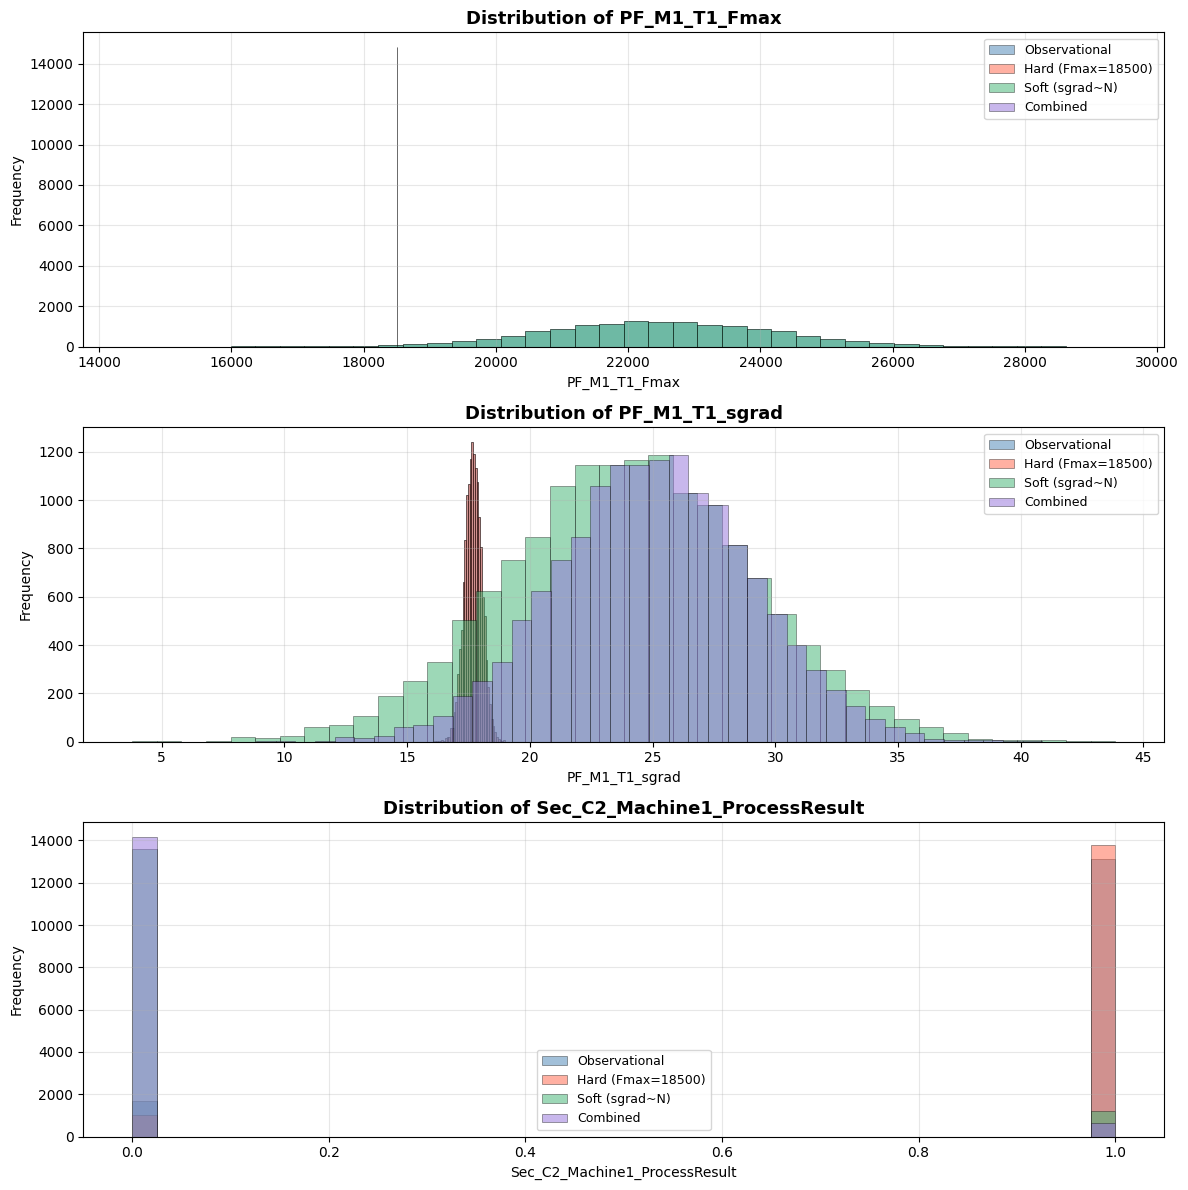

In [25]:
# --- Full comparison: 2x3 grid (Fmax, sgrad, downstream) x (all regimes) ---
datasets = {
    "Observational": df_obs,
    "Hard (Fmax=18500)": df_hard,
    "Soft (sgrad~N)": df_soft,
    "Combined": df_combined,
}
colors = {
    "Observational": "steelblue",
    "Hard (Fmax=18500)": "tomato",
    "Soft (sgrad~N)": "mediumseagreen",
    "Combined": "mediumpurple",
}

plot_vars = ["PF_M1_T1_Fmax", "PF_M1_T1_sgrad"]
if shared_downstream and shared_downstream in df_obs.columns:
    plot_vars.append(shared_downstream)

fig, axes = plt.subplots(len(plot_vars), 1, figsize=(12, 4 * len(plot_vars)))
if len(plot_vars) == 1:
    axes = [axes]

for i, var in enumerate(plot_vars):
    for label, df in datasets.items():
        if var in df.columns:
            # robust numeric extraction per dataset
            vals = df[var]
            if len(vals) > 0:
                axes[i].hist(vals, bins=40, alpha=0.5, label=label, color=colors[label], edgecolor="black", linewidth=0.5)
    axes[i].set_title(f"Distribution of {var}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "all_regimes_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary Statistics Across All Regimes

Let's compare the key statistics of the intervened variables across all four regimes in a single table.

In [26]:
# --- Summary table ---
summary_rows = []
for label, df in datasets.items():
    for var in ["PF_M1_T1_Fmax", "PF_M1_T1_sgrad"]:
        if var in df.columns:
            vals = df[var].dropna().astype(float).values
            if len(vals) == 0:
                mean_v = std_v = min_v = max_v = None
            else:
                mean_v = float(np.mean(vals))
                std_v = float(np.std(vals, ddof=1))
                min_v = float(np.min(vals))
                max_v = float(np.max(vals))
            summary_rows.append({
                "Regime": label,
                "Variable": var,
                "Mean":mean_v if mean_v is not None else None,
                "Std": std_v if std_v is not None else None,
                "Min": min_v if min_v is not None else None,
                "Max": max_v if max_v is not None else None,
            })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Regime,Variable,Mean,Std,Min,Max
0,Observational,PF_M1_T1_Fmax,22475.822555,1758.959980,14501.457348,29365.284324
1,Observational,PF_M1_T1_sgrad,17.675280,0.346064,16.099832,18.983660
2,Hard (Fmax=18500),PF_M1_T1_Fmax,18500.000000,0.000000,18500.000000,18500.000000
3,Hard (Fmax=18500),PF_M1_T1_sgrad,17.675280,0.346064,16.099832,18.983660
4,Soft (sgrad~N),PF_M1_T1_Fmax,22475.822555,1758.959980,14501.457348,29365.284324
5,Soft (sgrad~N),PF_M1_T1_sgrad,24.036504,4.992410,3.798261,43.846583
6,Combined,PF_M1_T1_Fmax,18500.000000,0.000000,18500.000000,18500.000000
7,Combined,PF_M1_T1_sgrad,25.029203,3.993928,8.838609,40.877267


## 8. Key Takeaways

| Aspect | Hard Intervention | Soft Intervention |
|--------|------------------|-------------------|
| **Syntax** | `{"var": constant}` | `{"var": "Normal('var', mu, sigma)"}` |
| **Graph surgery** | All incoming edges removed | All incoming edges removed |
| **Variable value** | Fixed constant | Sampled from new distribution |
| **Use case** | "What if we set this to exactly X?" | "What if this follows a different process?" |
| **Example** | Quality control at fixed setpoint | Switching to a different supplier |

**Key points:**
- Interventions are applied by setting `simulator.intervention_dict` before calling `simulator.sample()`. Alternatively, the simulator.apply_intervention(intervention: str) permits to define the intervention in the form of a sympy expression.
- Both hard and soft interventions perform **do-calculus graph mutilation** — the intervened variable becomes independent of its natural parents
- Multiple interventions (mixing hard and soft) can be applied simultaneously via a single dictionary
- Hard intervention values are numbers (`int` or `float`); soft intervention values are **sympy distribution strings** (e.g., `"Normal('name', mean, std)"`, `"Uniform('name', left, right)"`)
- The interventional table returned by `.sample()` records which variables were intervened on (useful for downstream causal analysis)
- Downstream variables are automatically recomputed given the intervention, propagating the causal effect through the entire graph